<a href="https://colab.research.google.com/github/241b163-dot/algo/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

Sample Input:  [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
Sample Output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]


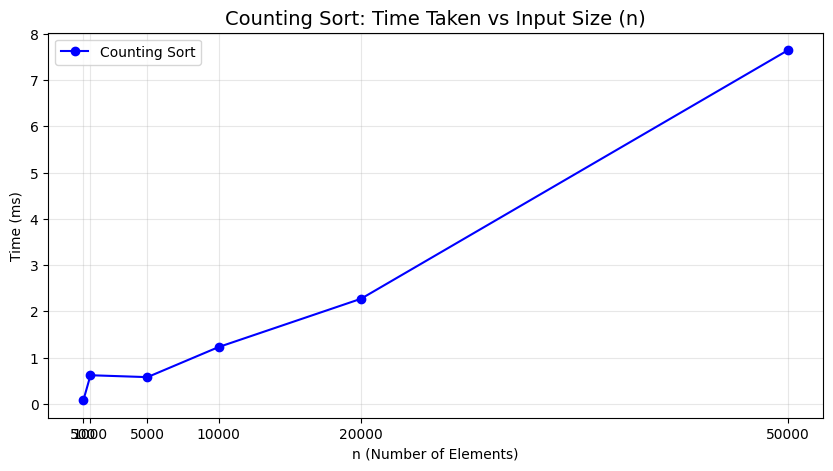

In [1]:
#Write a python program to perform Countingsort.
import timeit
import matplotlib.pyplot as plt
import numpy as np
import random

def counting_sort(arr):
    if not arr:
        return arr

    # 1. Find the maximum value to determine the number of buckets (k)
    k = max(arr)

    # 2. Create k+1 buckets initialized to 0
    # The index of the bucket represents the actual value from the input
    buckets = [0] * (k + 1)

    # 3. Iterate through the input and increment the counter in the bucket
    for num in arr:
        buckets[num] += 1

    # 4. Fill the input list with compressed data from the buckets
    i = 0
    for val in range(len(buckets)):
        # While the counter in the bucket is greater than zero
        while buckets[val] > 0:
            arr[i] = val
            i += 1
            buckets[val] -= 1

    return arr

# --- Sample Input Test ---
sample_input = [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
print(f"Sample Input:  {sample_input}")
sorted_output = counting_sort(sample_input.copy())
print(f"Sample Output: {sorted_output}")

# --- Performance Visualization ---

n_list = [500, 1000, 5000, 10000, 20000, 50000]
counting_times = []

for n in n_list:
    # Generate random integers between 0 and 500 (k is constant)
    test_data = [random.randint(0, 500) for _ in range(n)]

    start = timeit.default_timer()
    counting_sort(test_data)
    counting_times.append((timeit.default_timer() - start) * 1000)

# Plotting the relationship
plt.figure(figsize=(10, 5))
plt.plot(n_list, counting_times, marker='o', linestyle='-', color='blue', label='Counting Sort')
plt.xticks(n_list)
plt.title("Counting Sort: Time Taken vs Input Size (n)", fontsize=14)
plt.xlabel('n (Number of Elements)')
plt.ylabel('Time (ms)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


Sample Input:  [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
Sample Output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]

Starting Bucket Sort benchmarks...
n = 500 finished.
n = 1000 finished.
n = 2000 finished.
n = 5000 finished.
n = 10000 finished.
n = 15000 finished.


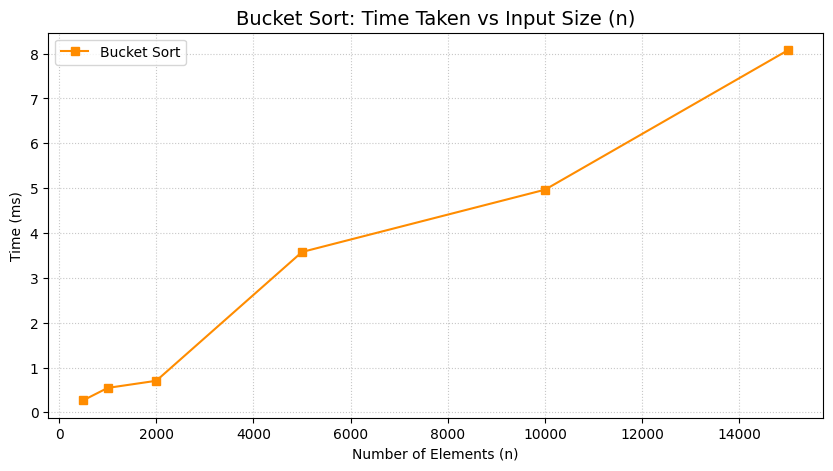

In [2]:
#write code for above cell and compute the running time and also plot graph.
import timeit
import matplotlib.pyplot as plt
import numpy as np
import random

def bucket_sort(arr):
    if len(arr) == 0:
        return arr

    # 1. Create buckets (using n buckets for n elements)
    bucket_count = len(arr)
    max_val = max(arr)
    min_val = min(arr)

    # Range of values to help distribute into buckets
    range_val = (max_val - min_val) / bucket_count

    # Initialize empty buckets
    buckets = [[] for _ in range(bucket_count + 1)]

    # 2. Scatter: Put array elements in different buckets based on the range
    for i in range(len(arr)):
        diff = (arr[i] - min_val) / range_val
        index = int(diff)
        buckets[index].append(arr[i])

    # 3. Sort individual buckets and Gather
    sorted_arr = []
    for bucket in buckets:
        # We use Python's sorted() (Timsort) for individual buckets
        sorted_arr.extend(sorted(bucket))

    return sorted_arr

# --- Sample Input Test ---
sample_input = [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
print(f"Sample Input:  {sample_input}")
sorted_output = bucket_sort(sample_input)
print(f"Sample Output: {sorted_output}")

# --- Performance Benchmarking ---

n_list = [500, 1000, 2000, 5000, 10000, 15000]
bucket_times = []

print("\nStarting Bucket Sort benchmarks...")
for n in n_list:
    # Uniform distribution is key for O(n) performance
    test_data = [random.randint(0, 10000) for _ in range(n)]

    start = timeit.default_timer()
    bucket_sort(test_data)
    end = timeit.default_timer()

    bucket_times.append((end - start) * 1000) # Convert to ms
    print(f"n = {n} finished.")

# --- Plotting ---
plt.figure(figsize=(10, 5))
plt.plot(n_list, bucket_times, marker='s', linestyle='-', color='darkorange', label='Bucket Sort')
plt.title("Bucket Sort: Time Taken vs Input Size (n)", fontsize=14)
plt.xlabel('Number of Elements (n)')
plt.ylabel('Time (ms)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

Sample Input:  [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
Sample Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]

Starting Radix Sort benchmarks...
n = 1000 finished.
n = 5000 finished.
n = 10000 finished.
n = 20000 finished.
n = 50000 finished.
n = 75000 finished.
n = 100000 finished.


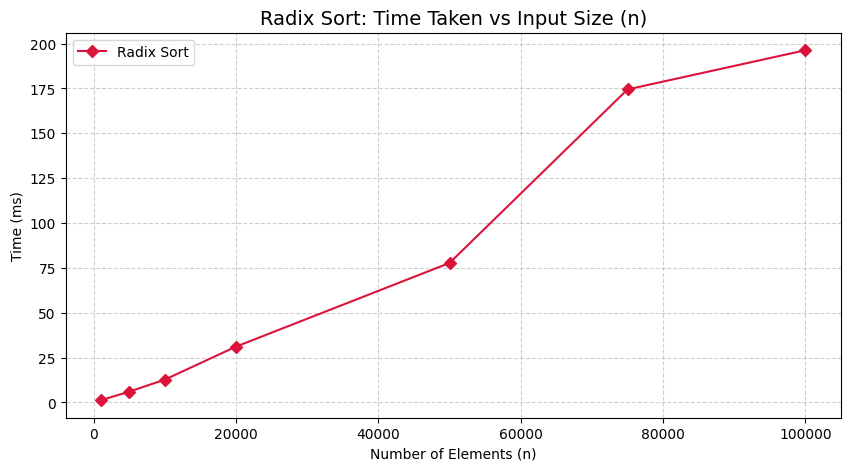

In [3]:
#write code for above cell and compute the running time and also plot graph.
import timeit
import matplotlib.pyplot as plt
import numpy as np
import random

def counting_sort_for_radix(arr, exp):
    n = len(arr)
    output = [0] * n
    count = [0] * 10  # 10 digits (0-9)

    # Store count of occurrences in count[]
    for i in range(n):
        index = (arr[i] // exp) % 10
        count[index] += 1

    # Change count[i] so that count[i] contains actual position
    # of this digit in output[]
    for i in range(1, 10):
        count[i] += count[i - 1]

    # Build the output array (Stable sort is essential here)
    i = n - 1
    while i >= 0:
        index = (arr[i] // exp) % 10
        output[count[index] - 1] = arr[i]
        count[index] -= 1
        i -= 1

    # Copy the output array to arr[]
    for i in range(len(arr)):
        arr[i] = output[i]

def radix_sort(arr):
    if len(arr) == 0:
        return arr

    # Find the maximum number to know number of digits
    max_val = max(arr)

    # Do counting sort for every digit. exp is 10^i where i is current digit
    exp = 1
    while max_val // exp > 0:
        counting_sort_for_radix(arr, exp)
        exp *= 10
    return arr

# --- Sample Input Test ---
sample_input = [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
print(f"Sample Input:  {sample_input}")
sorted_output = radix_sort(sample_input.copy())
print(f"Sample Output: {sorted_output}")

# --- Performance Benchmarking ---

n_list = [1000, 5000, 10000, 20000, 50000, 75000, 100000]
radix_times = []

print("\nStarting Radix Sort benchmarks...")
for n in n_list:
    # Generate random integers (range affects 'k')
    test_data = [random.randint(0, 100000) for _ in range(n)]

    start = timeit.default_timer()
    radix_sort(test_data)
    end = timeit.default_timer()

    radix_times.append((end - start) * 1000) # Convert to ms
    print(f"n = {n} finished.")

# --- Plotting ---
plt.figure(figsize=(10, 5))
plt.plot(n_list, radix_times, marker='D', linestyle='-', color='crimson', label='Radix Sort')
plt.title("Radix Sort: Time Taken vs Input Size (n)", fontsize=14)
plt.xlabel('Number of Elements (n)')
plt.ylabel('Time (ms)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()